# Matplotlib Practice

This notebook offers a set of exercises to different tasks with Matplotlib.

For further reference and resources, it's advised to check out the [Matplotlib documentation](https://matplotlib.org/3.1.1/contents.html).

In [7]:
# This line is used in Jupyter notebooks to enable the inline display of matplotlib plots.
%matplotlib inline 
# Import the pyplot module from matplotlib as plt 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

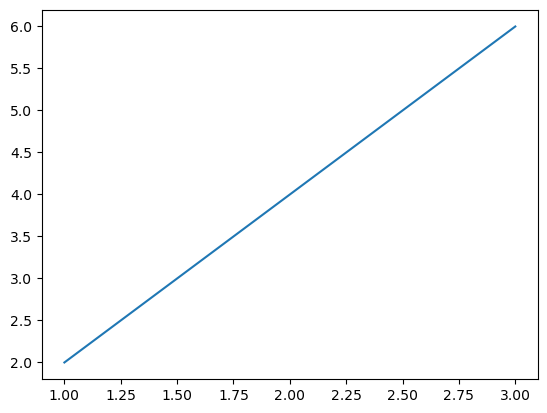

In [10]:
# Create a simple plot using plt.plot()
plt.plot([1,2,3],[2,4,6]); # adding the semicolon suppresses the output of the last line

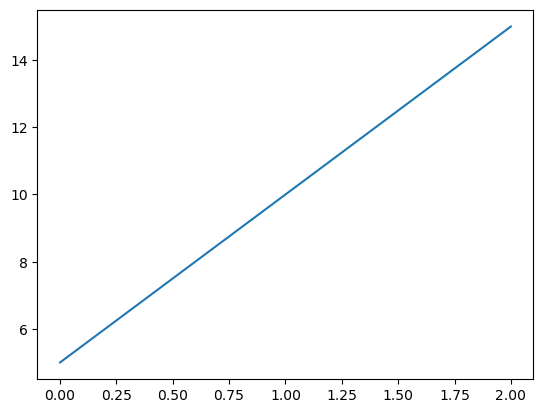

In [13]:
# Plot a single Python list
my_list = [5,10,15]
plt.plot(my_list);

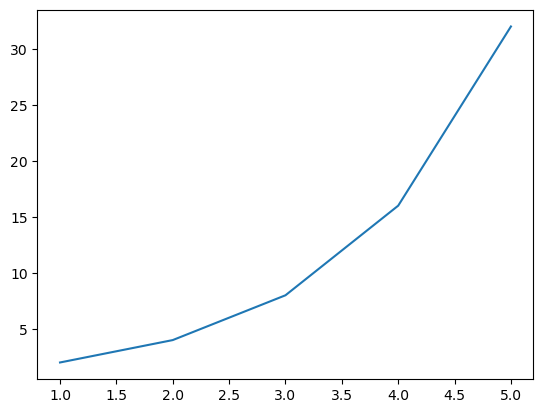

In [ ]:
# Create two lists, one called X, one called y, each with 5 numbers in them and plot.
x = [1,2,3,4,5]
y = [2,4,8,16,32]
plt.plot(x,y);

There's another way to create plots with Matplotlib, it's known as the object-orientated (OO) method. Let's try it.

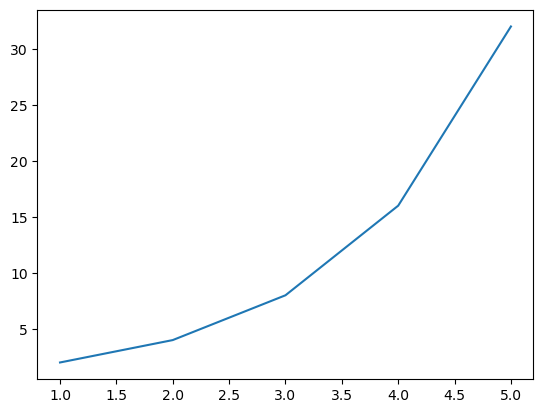

In [ ]:
# Create a plot using plt.subplots()
# Create a plot using plt.subplots() and then add X & y on the axes
fig, ax = plt.subplots()
ax.plot(x,y);

Matplotlib example workflow
Import and get matplotlib ready  
Prepare data (create two lists of 5 numbers, X & y)  
Setup figure and axes using plt.subplots()  
Add data (X, y) to axes  
Customize plot by adding a title, xlabel and ylabel  
Save the plot to file using fig.savefig()

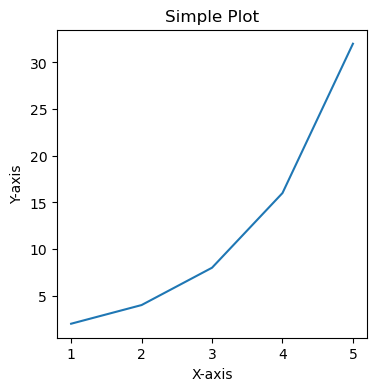

In [23]:
# Set up a plot, plot data, and add title, x-label and y-label
fig, ax = plt.subplots(figsize=(4,4)) # height and width in inches
ax.plot(x,y)
ax.set(title="Simple Plot",
       xlabel="X-axis",
       ylabel="Y-axis");
# Save and show
fig.savefig("simple-plot.png") # saves the figure to a file
plt.show() # displays the figure

In [ ]:
# Create an array of 100 evenly spaced numbers between 0 and 10 using NumPy and save it to variable X
x = np.linspace(0,10,100)

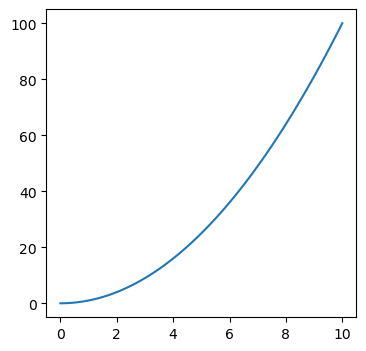

In [39]:
# Create a plot using plt.subplots() and plot X versus X^2 (X squared)
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(x, x**2);

## Scatter plots.

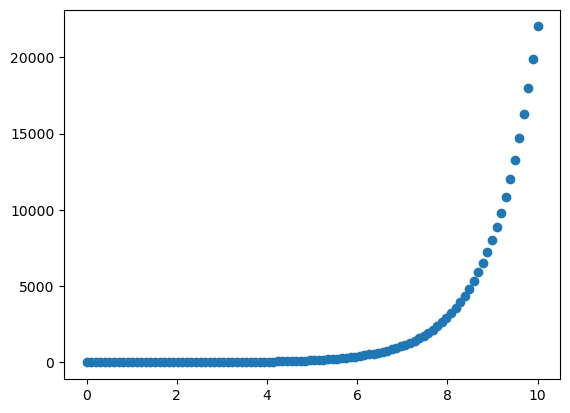

In [40]:
# Create a scatter plot of X versus the exponential of X (np.exp(X))
# First we have to reset plot
fig, ax = plt.subplots()
ax.scatter(x, np.exp(x));

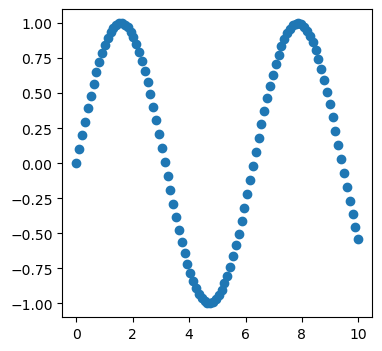

In [41]:
# Create a scatter plot of X versus np.sin(X)
fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(x, np.sin(x));

## Bar plots

In [43]:
# Create a Python dictionary of 3 of your favourite foods as keys paired with their price as values. 
fav_foods = {"pizza":5,
             "tacos":2,
             "wings":1}


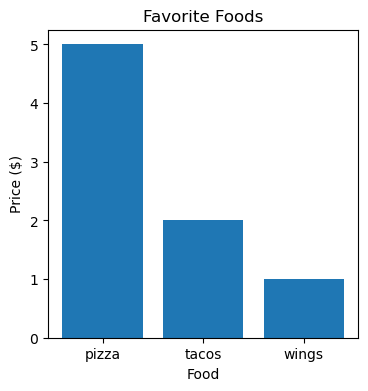

In [46]:
# Create a bar graph where the x-axis is the keys of the dictionary
# and the y-axis is the values of the dictionary
# Add a title, xlabel and ylabel to the plot
fig, ax = plt.subplots(figsize=(4,4))
ax.bar(fav_foods.keys(), fav_foods.values());
ax.set(title="Favorite Foods",
       xlabel="Food",
       ylabel="Price ($)");

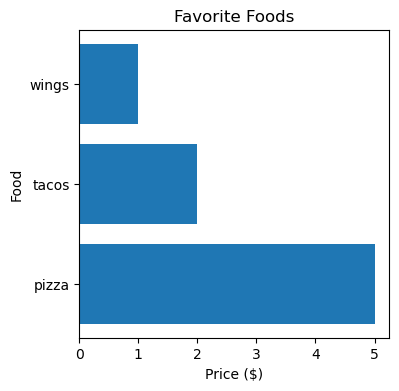

In [50]:
# Make the same plot as above, except this time make the bars go horizontal
fig, ax = plt.subplots(figsize=(4,4))
ax.barh(fav_foods.keys(), fav_foods.values()); # barh for horizontal bar plot
ax.set(title="Favorite Foods",
       ylabel="Food", # have to change the axis names as we flipped the axes
       xlabel="Price ($)");

## Histograms

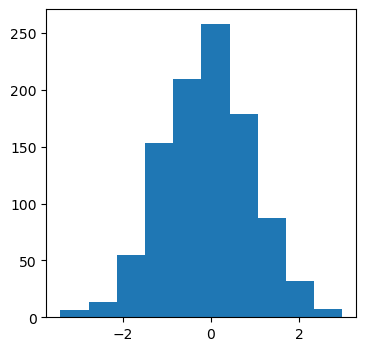

In [52]:
# Create a random NumPy array of 1000 normally distributed numbers using NumPy and save it to X
x = np.random.randn(1000)
# Create a histogram plot of X
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(x);

Now let's try make some subplots. A subplot is another name for a figure with multiple plots on it.

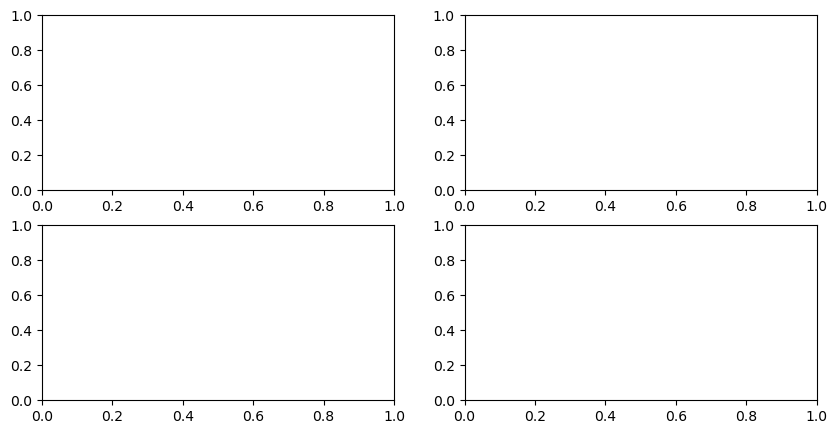

In [53]:
# Create an empty subplot with 2 rows and 2 columns (4 subplots total)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2,
                                             ncols=2,
                                            figsize=(10,5))

Notice how the subplot has multiple figures. Now let's add data to each axes.

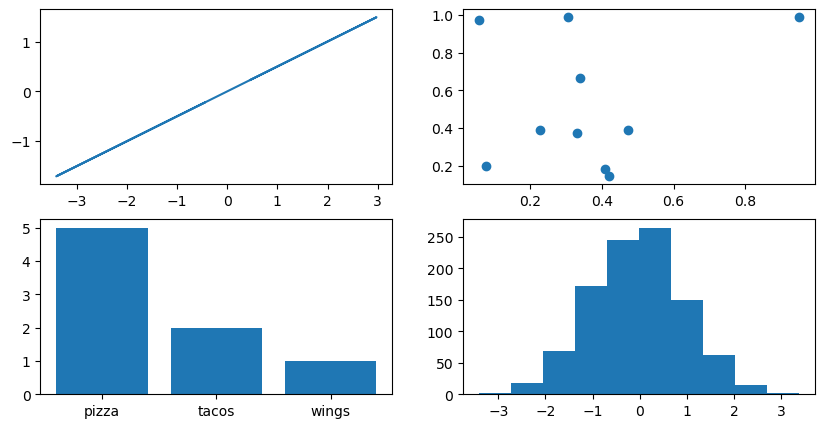

In [54]:
# Create the same plot as above with 2 rows and 2 columns and figsize of (10, 5)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2,
                                             ncols=2,
                                            figsize=(10,5))
# Plot X versus X/2 on the top left axes
ax1.plot(x,x/2);

# Plot a scatter plot of 10 random numbers on each axis on the top right subplot
ax2.scatter(np.random.random(10),np.random.random(10));

# Plot a bar graph of the favourite food keys and values on the bottom left subplot
ax3.bar(fav_foods.keys(), fav_foods.values());

# Plot a histogram of 1000 random normally distributed numbers on the bottom right subplot
ax4.hist(np.random.randn(1000));

In [65]:
# Import the '../data/car-sales.csv' into a DataFame called car_sales and view
car_sales = pd.read_csv("car-sales.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"


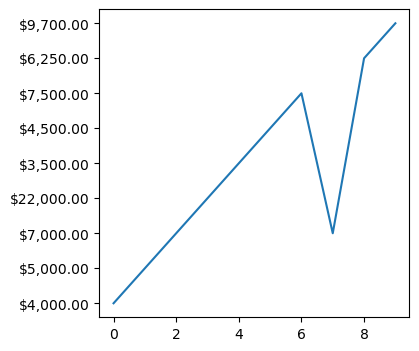

In [ ]:
# Try to plot the 'Price' column using the plot() function
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(car_sales["Price"]);

Why doesn't it work?

Hint: It's not numeric data.

In the process of turning it to numeric data, let's create another column which adds the total amount of sales and another one which shows what date the car was sold.

Hint: To add a column up cumulatively, look up the cumsum() function. And to create a column of dates, look up the date_range() function.

In [67]:
# Remove the symbols, the final two numbers from the 'Price' column and convert it to numbers
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$,\.]', '', regex=True).astype(int)

# Add a column called 'Total Sales' to car_sales which cumulatively adds the 'Price' column
car_sales["Total Sales"] = car_sales["Price"].cumsum()

# Add a column called 'Sale Date' which lists a series of successive dates starting from today (your today)
car_sales["Sales_Date"] = pd.date_range("12/04/2025", periods=len(car_sales))
# View the car_sales DataFrame
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price,Total Sales,Sales_Date
0,Toyota,White,150043,4,400000,400000,2025-12-04
1,Honda,Red,87899,4,500000,900000,2025-12-05
2,Toyota,Blue,32549,3,700000,1600000,2025-12-06
3,BMW,Black,11179,5,2200000,3800000,2025-12-07
4,Nissan,White,213095,4,350000,4150000,2025-12-08


Now we've got a numeric column (`Total Sales`) and a dates column (`Sale Date`), let's visualize them.

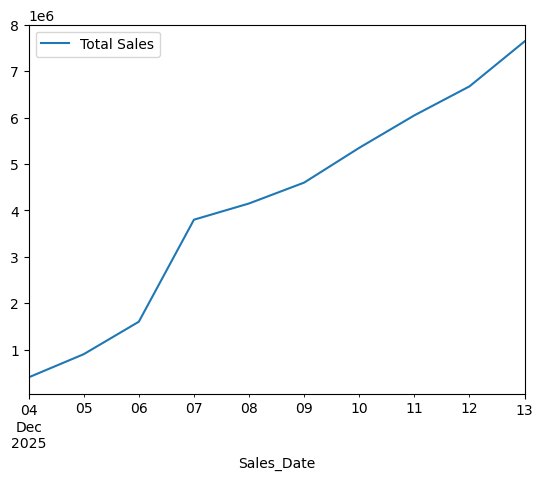

In [71]:
# Use the plot() function to plot the 'Sale Date' column versus the 'Total Sales' column
car_sales.plot(x="Sales_Date", y="Total Sales");

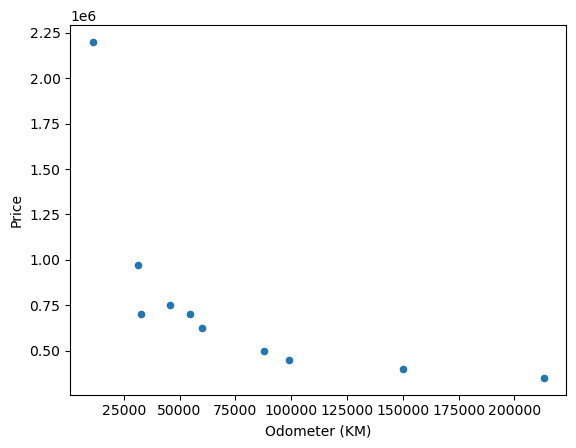

In [79]:
# Convert the 'Price' column to the integers
car_sales["Price"] = car_sales["Price"].astype(int)

# Create a scatter plot of the 'Odometer (KM)' and 'Price' column using the plot() function
car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter");

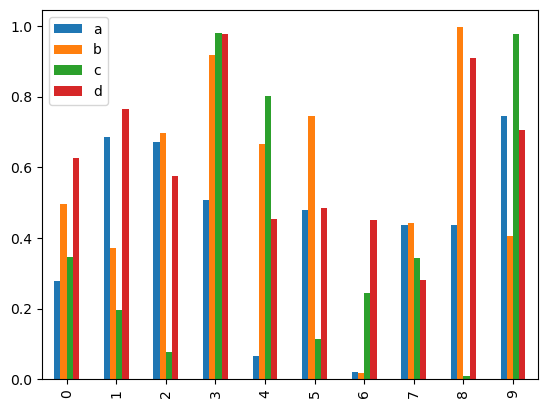

In [ ]:
# Create a NumPy array of random numbers of size (10, 4) and save it to X
x = np.random.rand(10,4)
# Turn the NumPy array X into a DataFrame with columns called ['a', 'b', 'c', 'd']
df = pd.DataFrame(x, columns=['a','b','c','d'])
# Create a bar graph of the DataFrame
df.plot.bar();
## df.plot(kind='bar') would also work

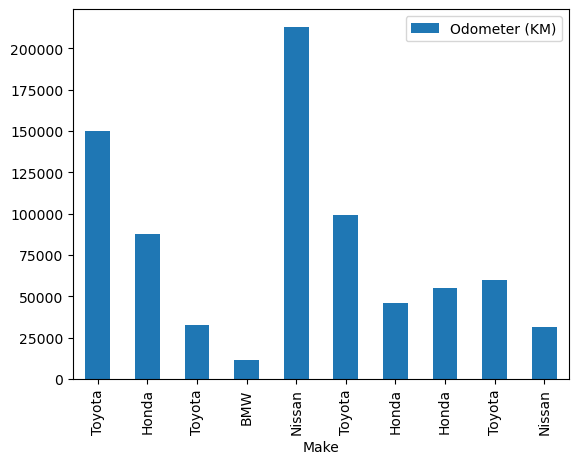

In [86]:
# Create a bar graph of the 'Make' and 'Odometer (KM)' columns in the car_sales DataFrame
car_sales.plot(x="Make", y="Odometer (KM)", kind="bar");

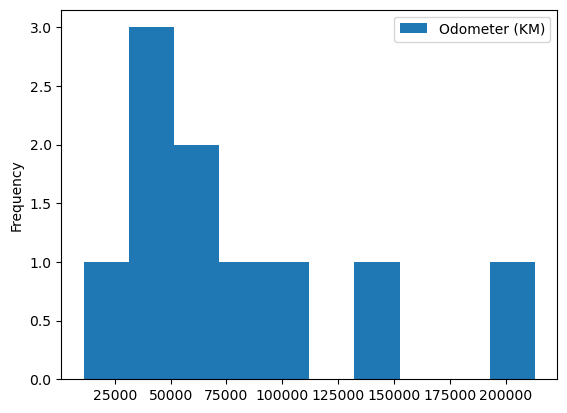

In [87]:
# Create a histogram of the 'Odometer (KM)' column
car_sales.plot(y="Odometer (KM)", kind="hist");

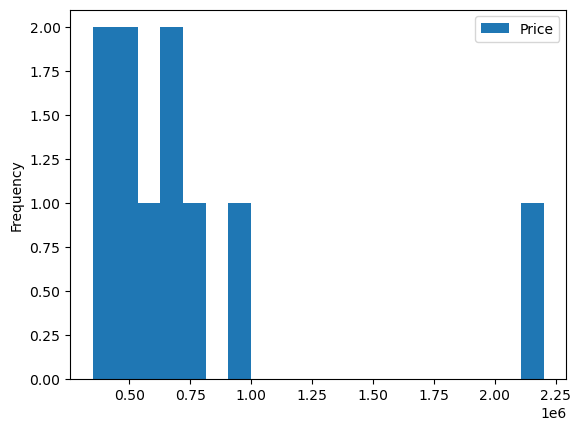

In [89]:
# Create a histogram of the 'Price' column with 20 bins
car_sales.plot(y="Price", kind="hist", bins=20);

In [93]:
# Import "../data/heart-disease.csv" and save it to the variable "heart_disease"
# View the first 10 rows of the heart_disease DataFrame
heart_disease = pd.read_csv("heart-disease.csv")
heart_disease.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


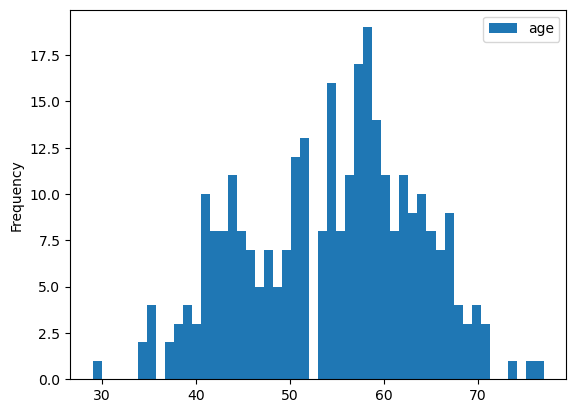

In [94]:
# Create a histogram of the "age" column with 50 bins
heart_disease.plot(y='age', kind='hist',bins=50);

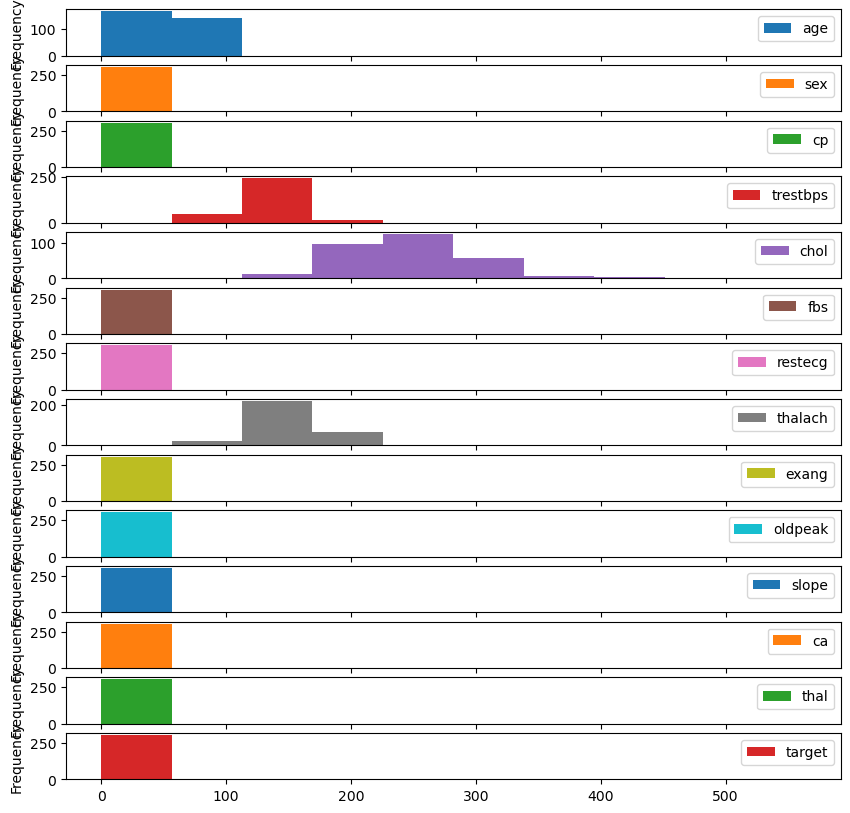

In [95]:
# Call plot.hist() on the heart_disease DataFrame and toggle the
# "subplots" parameter to True
heart_disease.plot.hist(subplots=True, figsize=(10,10));

That plot looks pretty squished. Let's change the figsize.

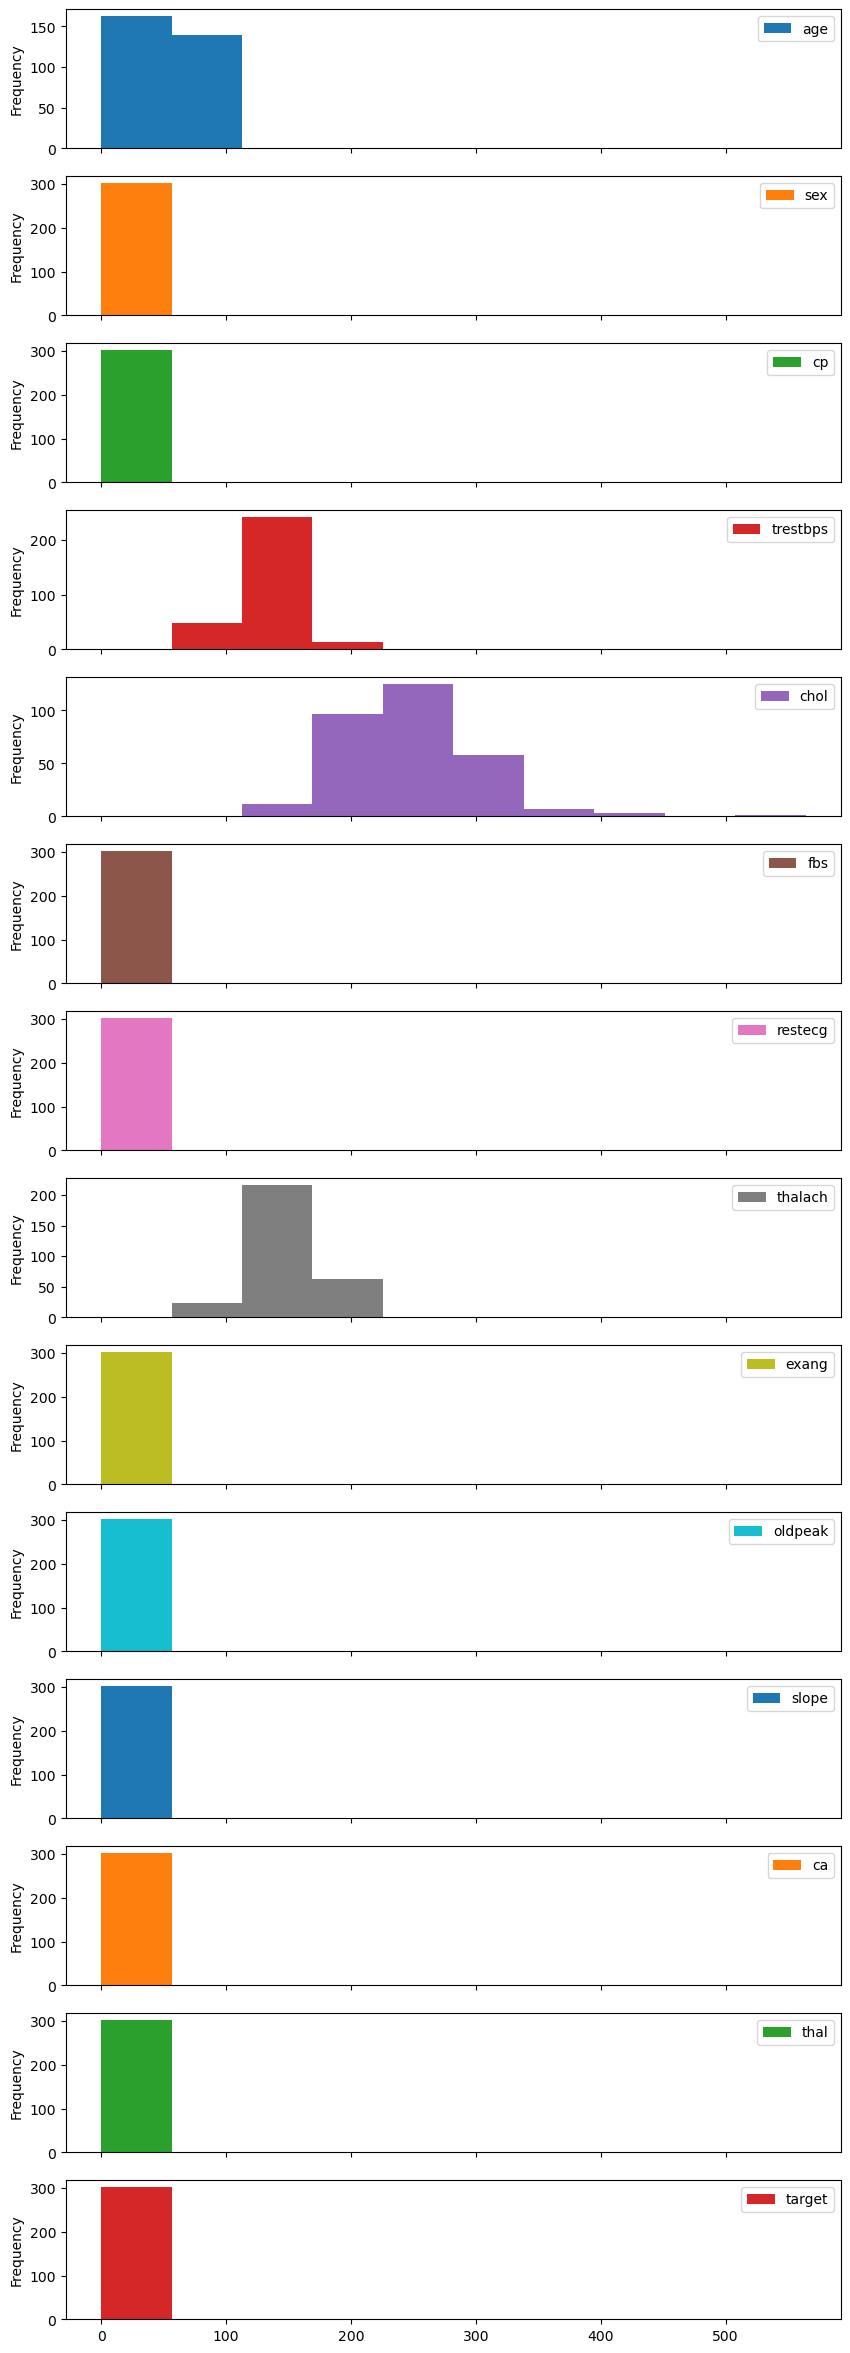

In [96]:
# Call the same line of code from above except change the "figsize" parameter
# to be (10, 30)
heart_disease.plot.hist(subplots=True, figsize=(10,30));

NOTE: when plotting something simple, use pyplot. If not, use 00 method

Now let's try comparing two variables versus the target variable.

More specifially we'll see how age and cholesterol combined effect the target in **patients over 50 years old**.

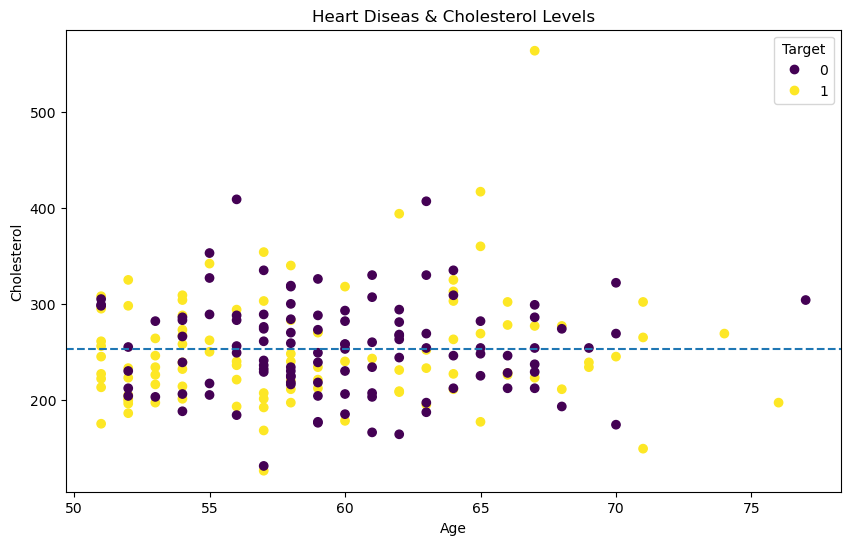

In [115]:
# Replicate the above plot in whichever way you see fit
# Create DataFrame with patients over 50 years old
over50 = heart_disease[heart_disease['age'] > 50]

# pyplot method:
# over50.plot(kind='scatter',x="age",y='chol',c='target');

# 00 (object oriented) method mixed with pyplot
# create plot
# fig, ax = plt.subplots(figsize=(10,6))
# Plot the data
# over50.plot(kind = 'scatter',
  #       x = 'age', 
    #     y = 'chol', 
      #   c = 'target',
        # ax = ax);
# could change x axis limits by ax.set_xlim([45-100])

# OO method from scratch
fig, ax = plt.subplots(figsize=(10,6))
# plot the data
scatter = ax.scatter(x=over50["age"],
                     y=over50["chol"],
                     c=over50["target"]);
# Customize the plot
ax.set(title="Heart Diseas & Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
# Add a legend
ax.legend(*scatter.legend_elements(), title="Target");
# Add a meanline
ax.axhline(over50["chol"].mean(),
           linestyle='--');

In [116]:
# Check what styles are available under plt
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [118]:
# Change the style to use "seaborn-whitegrid"
plt.style.use("seaborn-v0_8-whitegrid")

Now the style has been changed, we'll replot the same figure from above and see what it looks like.



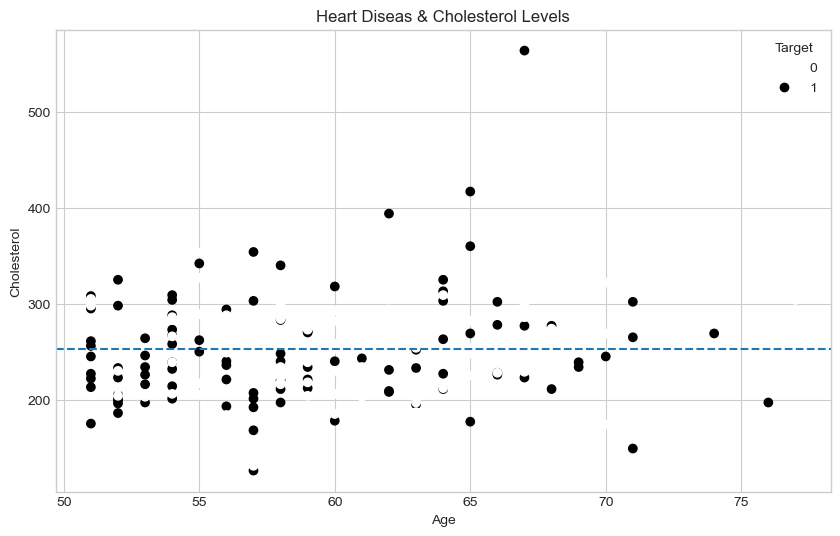

In [119]:
# Reproduce the same figure as above with the "seaborn-whitegrid" style

# Create the plot
fig, ax = plt.subplots(figsize=(10,6))

# Plot the data
scatter = ax.scatter(x=over50["age"],
                     y=over50["chol"],
                     c=over50["target"])

# Customize the plot
ax.set(title="Heart Diseas & Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
# Add a legend
ax.legend(*scatter.legend_elements(), title="Target");
# Add a meanline
ax.axhline(over50["chol"].mean(),
           linestyle='--');



Wonderful, you've changed the style of the plots and the figure is looking different but the dots aren't a very good colour.

Let's change the `cmap` parameter of `scatter()` as well as the `color` parameter of `axhline()` to fix it.

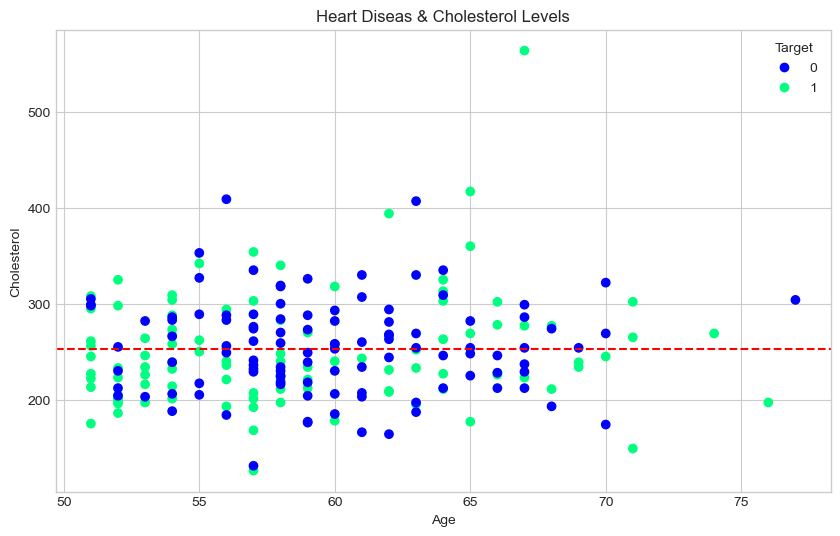

In [120]:
# Replot the same figure as above except change the "cmap" parameter
# of scatter() to "winter"
# Also change the "color" parameter of axhline() to "red"
# Reproduce the same figure as above with the "seaborn-whitegrid" style

# Create the plot
fig, ax = plt.subplots(figsize=(10,6))

# Plot the data
scatter = ax.scatter(x=over50["age"],
                     y=over50["chol"],
                     c=over50["target"],
                     cmap="winter")

# Customize the plot
ax.set(title="Heart Diseas & Cholesterol Levels",
       xlabel="Age",
       ylabel="Cholesterol");
# Add a legend
ax.legend(*scatter.legend_elements(), title="Target");
# Add a meanline
ax.axhline(over50["chol"].mean(),
           linestyle='--',
           color='red');



Beautiful! Now our figure has an upgraded color scheme let's save it to file.

In [121]:
# Save the current figure using savefig(), the file name can be anything you want
fig.savefig("heart-disease-cholesterol.png")

(<Figure size 640x480 with 1 Axes>, <Axes: >)

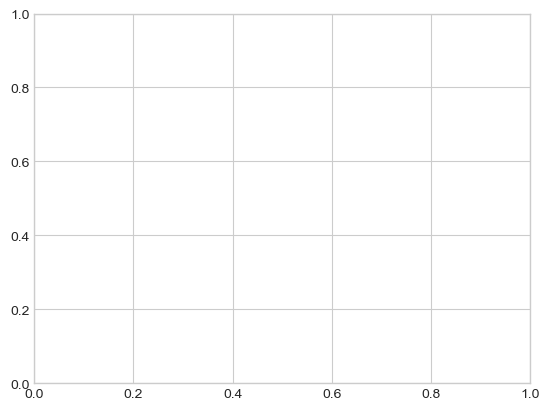

In [122]:
# Reset the figure by calling plt.subplots()
plt.subplots()